In [2]:
# task_2_data_preparation.ipynb

import pandas as pd
import os

# Define the correct local directory
data_dir = "C:\\Users\\ayedr\\week-1\\data\\yfinance_data"

# List of stock Excel files
stock_files = ["AAPL_historical_data.xlsx", "AMZN_historical_data.xlsx", "GOOG_historical_data.xlsx", "MSFT_historical_data.xlsx", "NVDA_historical_data.xlsx", "TSLA_historical_data.xlsx"]

# Dictionary to hold each stock's data
stock_data = {}

for file in stock_files:
    stock_name = file.split(".")[0]
    file_path = os.path.join(data_dir, file)

    # Load and preprocess
    df = pd.read_excel(file_path)
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure Date is datetime
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)
    
    stock_data[stock_name] = df

# Show sample data
stock_data["AAPL_historical_data"].head()


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.0,0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.0,0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.0,0


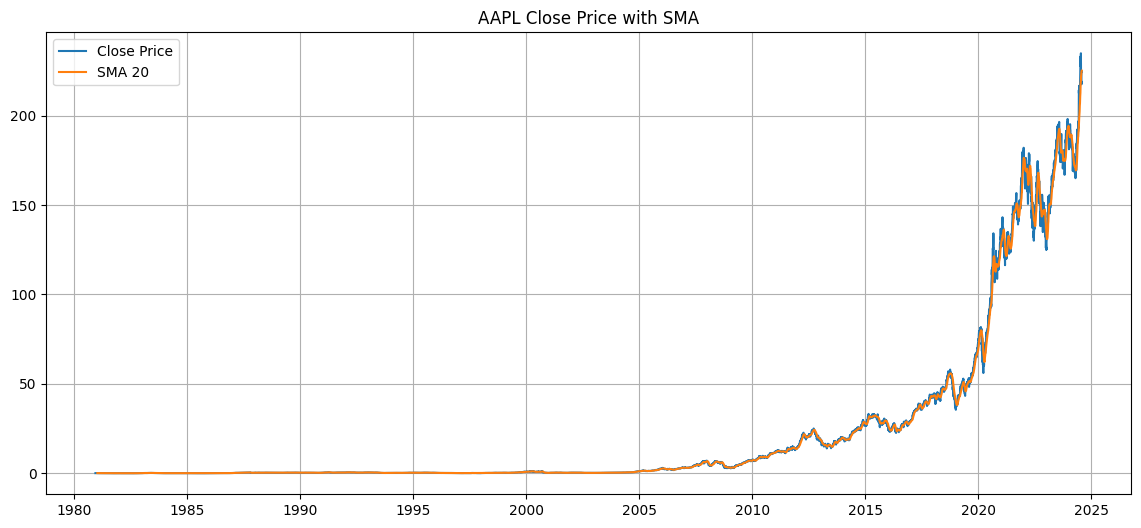

,MACD,MACD_signal
Date,,
2024-07-24,4.662717,6.678882
2024-07-25,3.748082,6.092722
2024-07-26,3.026267,5.479431
2024-07-29,2.448591,4.873263
2024-07-30,2.012764,4.301163


In [3]:
# task_2_technical_indicators.ipynb

import pandas as pd
import matplotlib.pyplot as plt
from ta.trend import SMAIndicator, MACD
from ta.momentum import RSIIndicator

# Example for one stock
df = stock_data["AAPL_historical_data"].copy()

# Add indicators
df['SMA_20'] = SMAIndicator(close=df['Close'], window=20).sma_indicator()
df['RSI'] = RSIIndicator(close=df['Close'], window=14).rsi()

macd = MACD(close=df['Close'])
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

# Plot example
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.title("AAPL Close Price with SMA")
plt.legend()
plt.grid()
plt.show()

# View the MACD section
df[['MACD', 'MACD_signal']].tail()


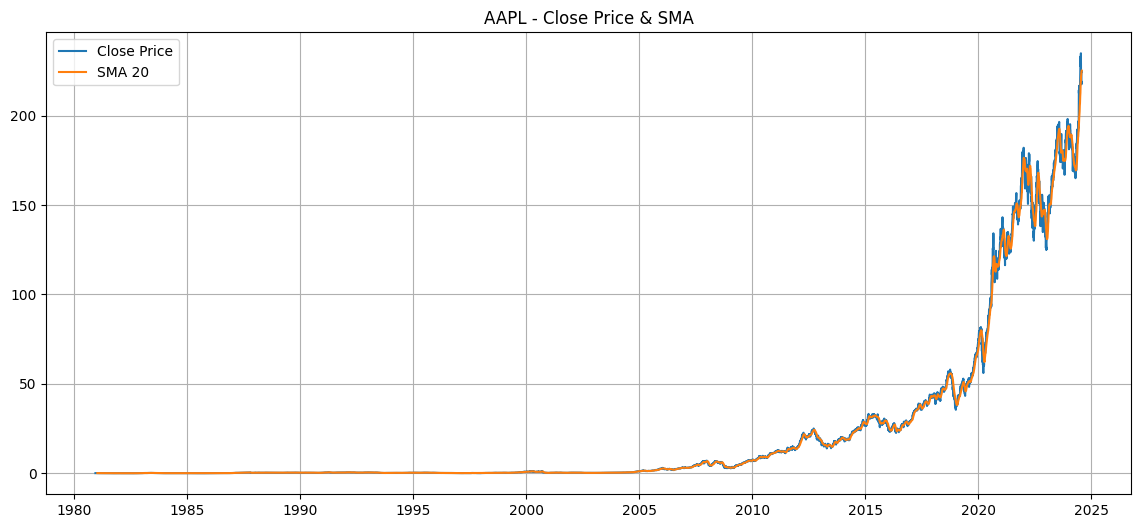

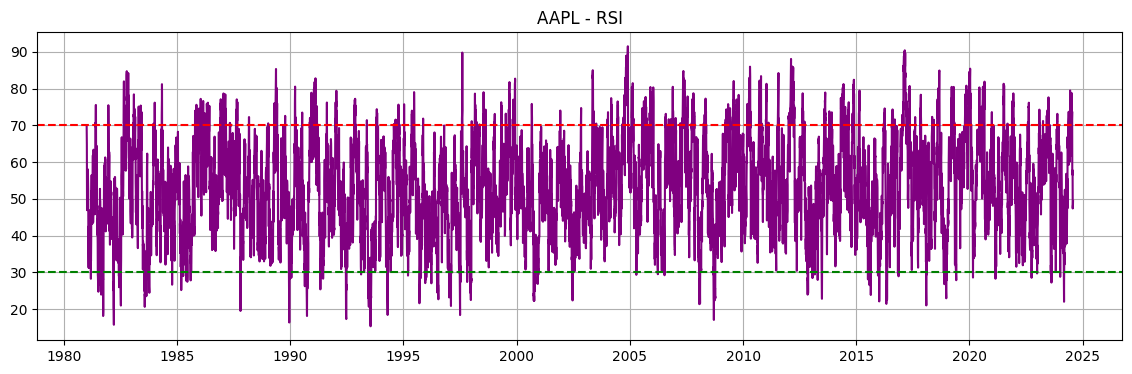

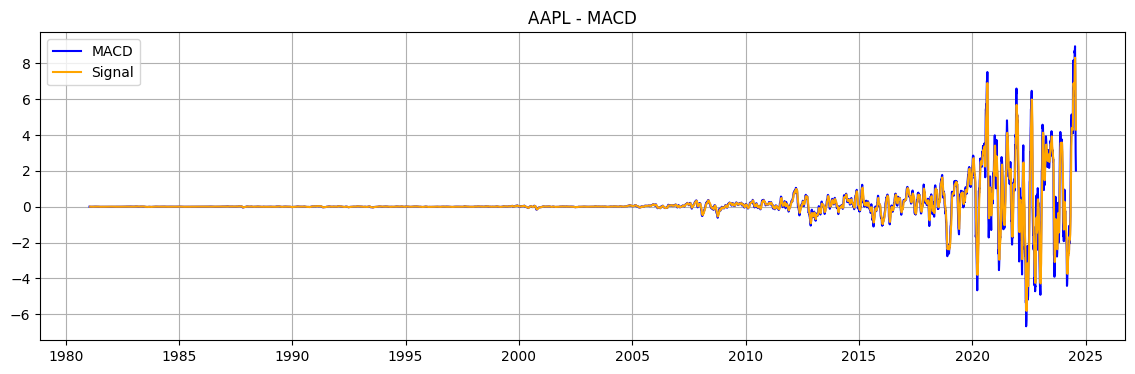

In [6]:
#Apply Technical Indicators to All Stocks
import pandas as pd
import ta

# Define dictionary to store indicators
stock_indicators = {}

for stock, df in stock_data.items():
    df = df.copy()
    
    # Indicators
    df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    
    macd = ta.trend.macd(df['Close'])
    df['MACD'] = macd
    df['MACD_signal'] = ta.trend.macd_signal(df['Close'])

    stock_indicators[stock] = df

#Save the Indicator-Enhanced Data
output_dir = "C:\\Users\\ayedr\\week-1\\data\\processed"

# Create the folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

for stock, df in stock_indicators.items():
    out_path = os.path.join(output_dir, f"{stock}_indicators.xlsx")
    df.to_excel(out_path)

#Visualize Each Indicator
import matplotlib.pyplot as plt

df = stock_indicators["AAPL_historical_data"]

# Plot SMA
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.title("AAPL - Close Price & SMA")
plt.legend()
plt.grid()
plt.show()

# Plot RSI
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['RSI'], color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("AAPL - RSI")
plt.grid()
plt.show()

# Plot MACD
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['MACD'], label='MACD', color='blue')
plt.plot(df.index, df['MACD_signal'], label='Signal', color='orange')
plt.title("AAPL - MACD")
plt.legend()
plt.grid()
plt.show()
